In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import copy
# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000       # Can change
NUM_PARTIES = 4       # Can change
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 10           # Number of redistricting simulations

NUM_CITIES = 5
CITY_INTENSITY = (5, 12)
CITY_SPREAD = (10, 30)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# ------------------------
# GENERATE POPULATION DENSITY
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ------------------------
# GENERATE VOTERS BASED ON DENSITY
# ------------------------
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# FIXED PARTY PREFERENCES
# ------------------------
voter_parties = np.random.randint(0, NUM_PARTIES, NUM_VOTERS)
voter_colors = party_colors[voter_parties]
def connected_districts(voters, num_districts, voters_per_district, k_neighbors=20):
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    # Create districts with BFS
    for d in range(num_districts):
        if not unassigned:
            break

        seed = np.random.choice(list(unassigned))
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        # Retry if district incomplete
        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            return connected_districts(voters, num_districts, voters_per_district)

    # ------------------------
    # Assign leftover voters to nearest district
    # ------------------------
    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]

    return district
# ------------------------
# COUNT VOTES
# ------------------------
def count_votes(district_labels):
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts


# ------------------------
# EFFICIENCY GAP (2-party only)
# ------------------------
def efficiency_gap(district_counts):
    if NUM_PARTIES != 2:
        return None
    wasted = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for d in district_counts:
        total = sum(d.values())
        total_votes += total
        winner = max(d, key=d.get)
        for party in PARTY_IDS:
            if party == winner:
                wasted[party] += d[party] - total / 2
            else:
                wasted[party] += d[party]

    return (wasted[PARTY_IDS[0]] - wasted[PARTY_IDS[1]]) / total_votes

def get_is_winner(district_counts, target_party):
    """
    Returns True if target_party has more votes than all others.
    If there is any tie for the maximum, the target party loses.
    """
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    
    # Target must be strictly greater than every other party
    return all(target_votes > v for v in other_votes)

def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    
    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            # Best effort: move 1 vote from each competitor to target
            moved = 0
            for p in competitors:
                if d[p] > 0:
                    d[p] -= 1
                    moved += 1
            if moved > 0:
                d[target_party] += moved
                any_shift = True
        
        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins
            
        if not any_shift or new_wins == NUM_DISTRICTS:
            break
    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0} # Share calculated externally

def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)
    
    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            # Best effort: move up to (n-1) votes away from target
            to_remove = min(d[target_party], num_competitors)
            if to_remove > 0:
                d[target_party] -= to_remove
                # Distribute those votes one by one to competitors
                for i in range(to_remove):
                    d[competitors[i % num_competitors]] += 1
                any_shift = True
        
        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins
            
        if not any_shift or new_wins == 0:
            break
    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


# 1. Update your simulation functions to return the current vote share
def get_current_vote_share(district_counts, target_party):
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total

# 2. Updated compute function
def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    # Calculate starting state
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))
    
    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)

    # Base point is the current status of the party
    base_point = (initial_vote, initial_wins)

    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]

    merged = sorted(set(fwd_points + rev_points))
    return merged

# 3. Improved plotting function
def plot_step_and_complement(step_points, NUM_DISTRICTS, title="Seat–Vote Curve"):
    x, y = zip(*sorted(step_points))
    x, y = np.array(x), np.array(y)

    plt.figure(figsize=(8, 6))
    
    # Original curve: where="post" is good, but ensure x starts at 0 and ends at 1
    plt.step(x, y, where="post", color="black", label="Seat–Vote Curve", lw=2)

    # Complement curve: (1-x, N-y)
    xc = 1 - x
    yc = NUM_DISTRICTS - y
    
    # Sort by xc for proper plotting
    order = np.argsort(xc)
    plt.step(xc[order], yc[order], where="post", color="blue", label="Complement Curve", linestyle="--")

    plt.xlabel("Statewide Vote Share")
    plt.ylabel("Districts Won")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, NUM_DISTRICTS)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()
    
def compute_step_function_area(step_points, num_districts):
    """
    Computes the geometric area between the seat–vote curve and its complement curve.

    Parameters:
        step_points: list of (vote_share, districts_won) tuples
        num_districts: total number of districts

    Returns:
        Dictionary with:
            - area_between: area between the two curves
            - area_step: area under the seat–vote curve
            - area_complement: area under the complement curve
    """
    # Sort points by vote share
    points = sorted(step_points, key=lambda x: x[0])
    
    # Ensure endpoints at 0 and 1
    if points[0][0] > 0:
        points = [(0,0)] + points
    if points[-1][0] < 1.0:
        points = points + [(1.0, points[-1][1])]
    
    # Build the complement curve: g(x) = N - f(1-x)
    step_x, step_y = zip(*points)
    step_x, step_y = np.array(step_x), np.array(step_y)

    # Combine all x-breakpoints from both curves
    complement_x = 1 - step_x[::-1]
    complement_y = num_districts - step_y[::-1]

    all_x = np.unique(np.concatenate([step_x, complement_x]))
    area_between = 0.0
    area_step = 0.0
    area_complement = 0.0

    # Evaluate step values in each interval
    def step_value_at(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        idx = max(0, idx)
        return ys[idx]

    for i in range(len(all_x)-1):
        x1 = all_x[i]
        x2 = all_x[i+1]
        width = x2 - x1

        f_val = step_value_at((x1+x2)/2, step_x, step_y)
        g_val = step_value_at((x1+x2)/2, complement_x, complement_y)

        area_between += width * abs(f_val - g_val)
        area_step += width * f_val
        area_complement += width * g_val

    return {
        "area_between": area_between,
        "area_step": area_step,
        "area_complement": area_complement
    }


# ------------------------
# RUN SIMULATIONS
# ------------------------
all_efficiency_gaps = []
all_seat_counts = []
all_vote_shares = []       # Party 0 only, optional
all_seat_shares = []       # Party 0 only, optional
all_pr_vote_shares = []    # dict of all parties
all_pr_seat_shares = []    # dict of all parties
all_district_counts = []    # For potential further analysis
all_area_results = []    # For step function area analysis
all_step_curves = []       # Store step curves for potential plotting
plt.figure(figsize=(10,6))

for run in range(NUM_RUNS):
    district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)
    district_counts = count_votes(district_labels)

    # Efficiency gap
    gap = efficiency_gap(district_counts)
    all_efficiency_gaps.append(gap)

    # ------------------------
    # Proportional Representation (all parties)
    # ------------------------
    pr_vote_share = {party: 0 for party in PARTY_IDS}
    pr_seat_share = {party: 0 for party in PARTY_IDS}

    for d in district_counts:
        for party in PARTY_IDS:
            pr_vote_share[party] += d[party]

    # Normalize vote share
    total_votes = sum(pr_vote_share.values())
    for party in PARTY_IDS:
        pr_vote_share[party] /= total_votes

    # Seat share
    for d in district_counts:
        winner = max(d, key=d.get)
        pr_seat_share[winner] += 1
    for party in PARTY_IDS:
        pr_seat_share[party] /= NUM_DISTRICTS

    all_pr_vote_shares.append(pr_vote_share)
    all_pr_seat_shares.append(pr_seat_share)
    all_district_counts.append(district_counts)
    # -----------------------------------------
# STEP CURVES FOR EACH PARTY (per simulation)
# -----------------------------------------

    step_curves_this_run = {}
    area_results_this_run = {}

    for party in PARTY_IDS:
        curve = compute_step_curve_for_party(
            district_counts,
            party,
            PARTY_IDS,
            NUM_DISTRICTS
        )
        step_curves_this_run[party] = curve
        area_metrics = compute_step_function_area(curve, NUM_DISTRICTS)
        area_results_this_run[party] = area_metrics

# Store all curves for this simulation
all_step_curves.append(step_curves_this_run)
all_area_results.append(area_results_this_run)



# ------------------------
# SCATTER PLOT: Vote Share vs Seat Share
# ------------------------
plt.figure(figsize=(8,8))
for party in PARTY_IDS:
    vote_shares = [run[party] for run in all_pr_vote_shares]
    seat_shares = [run[party] for run in all_pr_seat_shares]
    plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)

plt.plot([0,1],[0,1], linestyle='--', color='black', label='Perfect Proportionality')
plt.xlabel("Vote Share")
plt.ylabel("Seat Share")
plt.title("Seat Share vs Vote Share per Party")
plt.xlim(0,1)
plt.ylim(0,1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ------------------------
# SUMMARY
# ------------------------
print("\n----- REDISTRICTING SUMMARY -----")
print("Runs:", NUM_RUNS)
if NUM_PARTIES == 2:
    print("Mean Efficiency Gap:", np.nanmean(all_efficiency_gaps))
    print("Std Efficiency Gap:", np.nanstd(all_efficiency_gaps))
for party in PARTY_IDS:
    mean_vote = np.mean([run[party] for run in all_pr_vote_shares])
    mean_seat = np.mean([run[party] for run in all_pr_seat_shares])
    print(f"{party}: Mean Vote Share = {mean_vote:.3f}, Mean Seat Share = {mean_seat:.3f}")

    

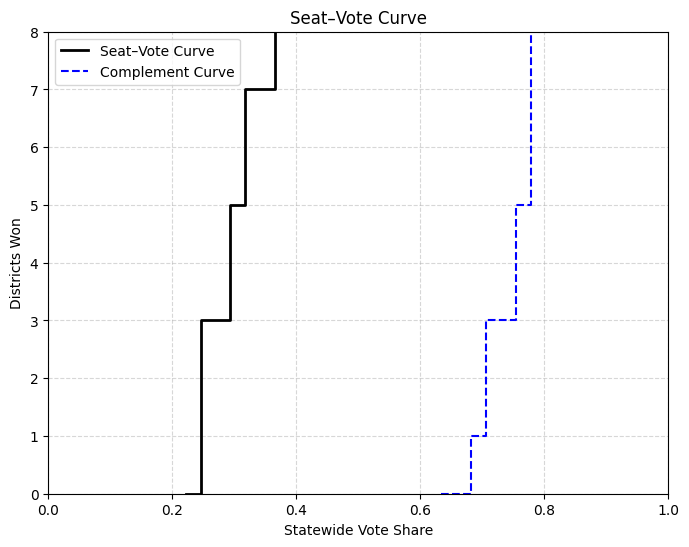

Area Step: 5.672000000000001
Area Complement: 2.064
Area Difference (Bias): 3.608


In [ ]:
plot_step_and_complement(all_step_curves[0]["Party 1"], NUM_DISTRICTS)
# Access the dictionary for the first run, then the specific party
party_0_run_0_metrics = all_area_results[0]["Party 1"]

# Now you can print individual components
print("Area Step:", party_0_run_0_metrics["area_step"])
print("Area Complement:", party_0_run_0_metrics["area_complement"])
print("Area Difference (Bias):", party_0_run_0_metrics["area_between"])


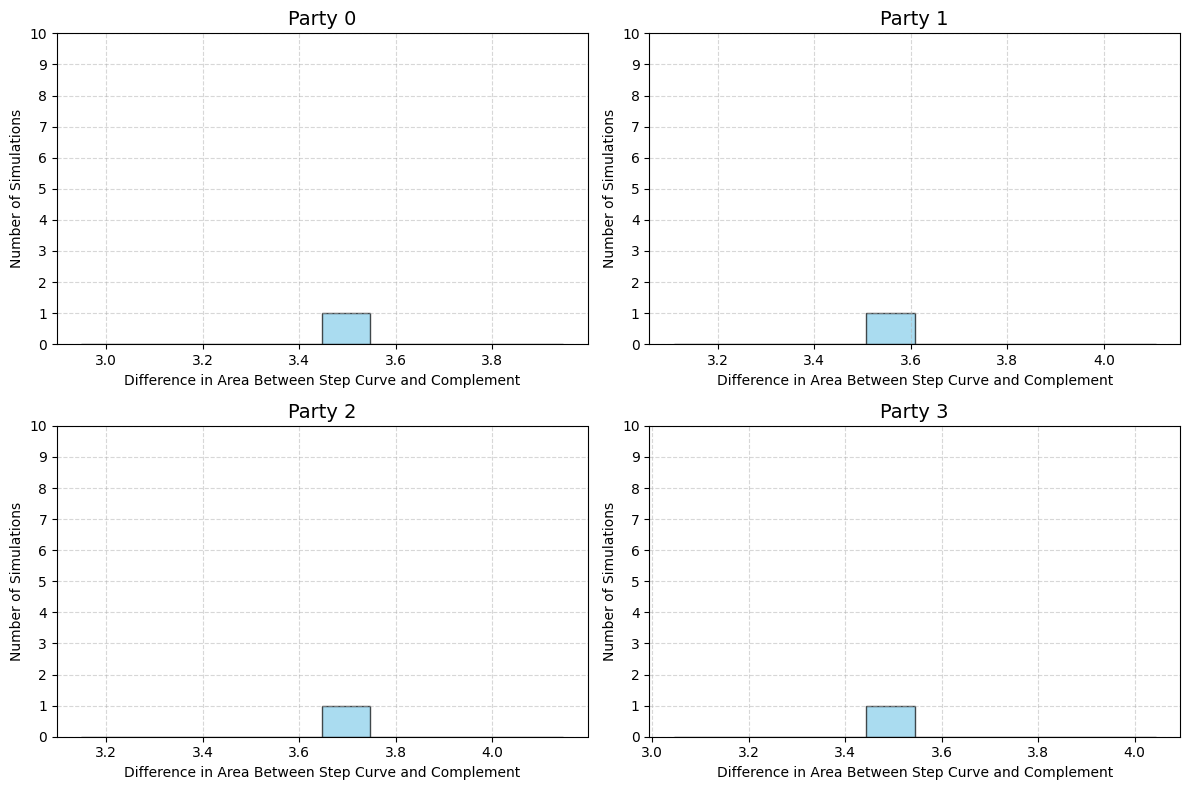

In [ ]:
import matplotlib.pyplot as plt
import math

# ------------------------
# Grid layout
# ------------------------
n_parties = len(PARTY_IDS)
n_cols = 2  # number of columns in the grid
n_rows = math.ceil(n_parties / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()  # flatten so we can index easily

# ------------------------
# Plot histograms per party
# ------------------------
for i, party in enumerate(PARTY_IDS):
    # Collect area_between values for this party across all simulations
    area_differences = [
        area_results_this_run[party]["area_between"]
        for area_results_this_run in all_area_results
        if party in area_results_this_run
    ]
    
    axes[i].hist(area_differences, bins=NUM_RUNS, alpha=0.7, color='skyblue', edgecolor='black', density=False)
    axes[i].set_title(f"{party}", fontsize=14)
    axes[i].set_xlabel("Difference in Area Between Step Curve and Complement")
    axes[i].set_ylabel("Number of Simulations")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].set_yticks(range(0, NUM_RUNS+1))  # integer counts

# Hide any extra subplots if n_parties is not a multiple of n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
district_counts 

[{'Party 0': 33, 'Party 1': 21, 'Party 2': 34, 'Party 3': 37},
 {'Party 0': 31, 'Party 1': 30, 'Party 2': 40, 'Party 3': 24},
 {'Party 0': 33, 'Party 1': 28, 'Party 2': 34, 'Party 3': 30},
 {'Party 0': 25, 'Party 1': 35, 'Party 2': 34, 'Party 3': 31},
 {'Party 0': 32, 'Party 1': 31, 'Party 2': 37, 'Party 3': 25},
 {'Party 0': 33, 'Party 1': 34, 'Party 2': 27, 'Party 3': 31},
 {'Party 0': 39, 'Party 1': 31, 'Party 2': 28, 'Party 3': 27},
 {'Party 0': 30, 'Party 1': 36, 'Party 2': 35, 'Party 3': 24}]

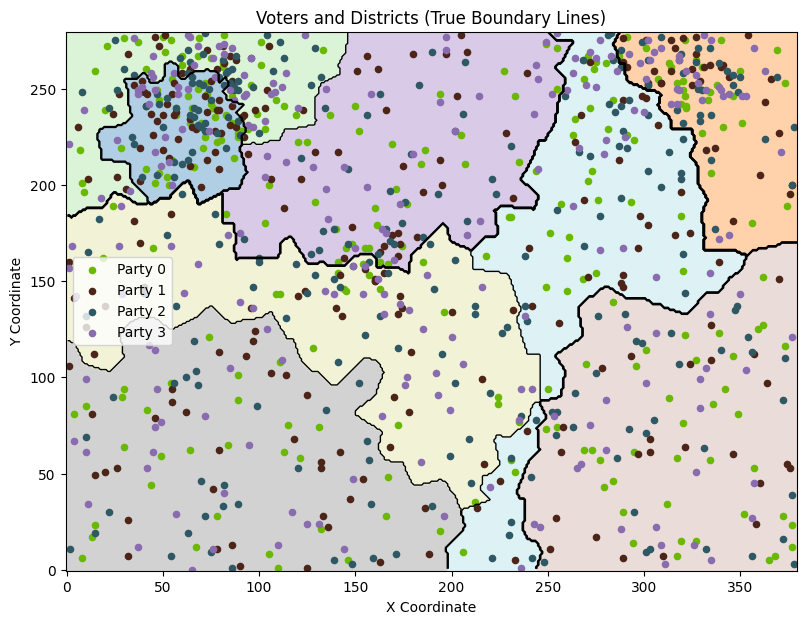

In [ ]:
# ------------------------
# VISUALIZE ONE RUN (NO OVERLAP)
# ------------------------

district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)

# Build KD-tree for fast nearest lookup
tree = cKDTree(voters)

# Create grid of every pixel
xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

# Assign each pixel to nearest voter
_, nearest_voter = tree.query(grid_points)
pixel_districts = district_labels[nearest_voter]
pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

plt.figure(figsize=(10,7))

# Lightly color districts
plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)

# Draw district boundaries
plt.contour(
    pixel_map,
    levels=np.arange(NUM_DISTRICTS)+0.5,
    colors='black',
    linewidths=1,
    origin='lower'
)

# Plot voters on top
for i, party in enumerate(PARTY_IDS):
    mask = voter_parties == i
    plt.scatter(
        voters[mask,0],
        voters[mask,1],
        color=PARTY_COLORS[party],
        label=party,
        s=20
    )

plt.title("Voters and Districts (True Boundary Lines)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

